# Pattern Evaluation Beyond Metrics
本檔案旨在針對模型評估（Evaluation）階段的各項指標與分析步驟，進行更深一層的業務與實務層面解讀。不僅僅是比較數字高低，而是探討這些數字在「先買後付信用風險預測」真實情境中代表的意義，以及如果將模型落地應用，會產生哪些潛在的影響與限制。

## 說明 Evaluation 的各步驟情境意義

### 步驟一：檢視預測機率的分桶違約率（機率校準度）
進行模型對於資料集整體的表現會忽略了在不同機率群組的 local 表現。因此分桶檢測可以評估在不同輸出機率區間下預測的機率平均是否為 `default_flag = 1 `的比例。
且在實務上模型不該只是評估 **是否違約** ，而該考慮的是違規風險為多少。

### 步驟二：ROC-AUC 與 AUC-PR
ROC-AUC 衡量了模型區分好壞客戶的整體能力，不受閾值影響；但由於資料中存在類別不平衡（違約人數遠少於準時付款），AUC-PR（Precision-Recall 曲線下的面積）更能反映模型在少數類別（違約客群）上的預測品質。這兩個指標幫助我們確認模型是否有真正捕捉到高風險客戶特徵。

### 步驟三、四：最佳化決策門檻與各項分類指標
在先買後付場景中，漏抓違約客戶（偽陰性，False Negative）的成本通常遠高於誤判好客戶（偽陽性，False Positive）。因此我們不能使用預設的 0.5 作為閾值。尋找 F2-Score 最佳化門檻（更看重 Recall）是為了在盡可能多抓出潛在違約者的同時，控制誤判正常使用者的數量。而混淆矩陣與各項指標則具體呈現了在這個門檻下，預期的授信通過率以及可能的違約損失比例。

## 比較三種模型在各步驟評估下的表現
根據先前評估階段的結果，以下依序總結各模型在每個步驟的表現：

### 步驟一：機率校準度 (Calibration)
DNN 明顯比其餘兩者的猜違約機率方面還要強。
- **隨機森林 (Random Forest)** 表現平穩居次 (Calibration Score: 7.9%)，與 XGBoost 相似，但在居中區域誤差明顯。
- **XGBoost** 校準度表現最差 (Calibration Score: 7.3%)，與隨機森林相似，除在 0~10,30~40,70~80 區段，其餘區段預測誤差明顯。
- **DNN** 表現最佳 (Calibration Score: 3.2%)，預測機率與實際違約率最為貼近。

### 步驟二：區分能力 (ROC-AUC 與 AUC-PR)
三模型差別不大，而 ROC-AUC 顯示成功找出違約者比誤報還多；AUC-PR 顯示 precision 下的成功找出違約者比例。
因為 `default_flag` 比例不均勻，且我們預設傾向是 recall 盡量高，所以 AUC-PR 參考價值較大。
- **隨機森林** 表現居中。 ROC-AUC 為 75.95%，AUC-PR 為 68.96%。
- **XGBoost** 表現最差 ROC-AUC 75.77% 與 AUC-PR 68.08%。
- **DNN** 表現最佳，ROC-AUC 為 76.87%，AUC-PR 69.96%。

### 步驟三、四: 在 0.5 門檻和 F2 Score Recall 最佳化門檻下個指標
#### 混淆矩陣
在 0.5 門檻下 **隨機森林**、**XGBoost** TP >> FN, TN > FT ，而 DNN 明顯都預測 0。
在 F2 Score 最佳化門檻下三者都嚴重偏重預測 1。

#### 其他指標

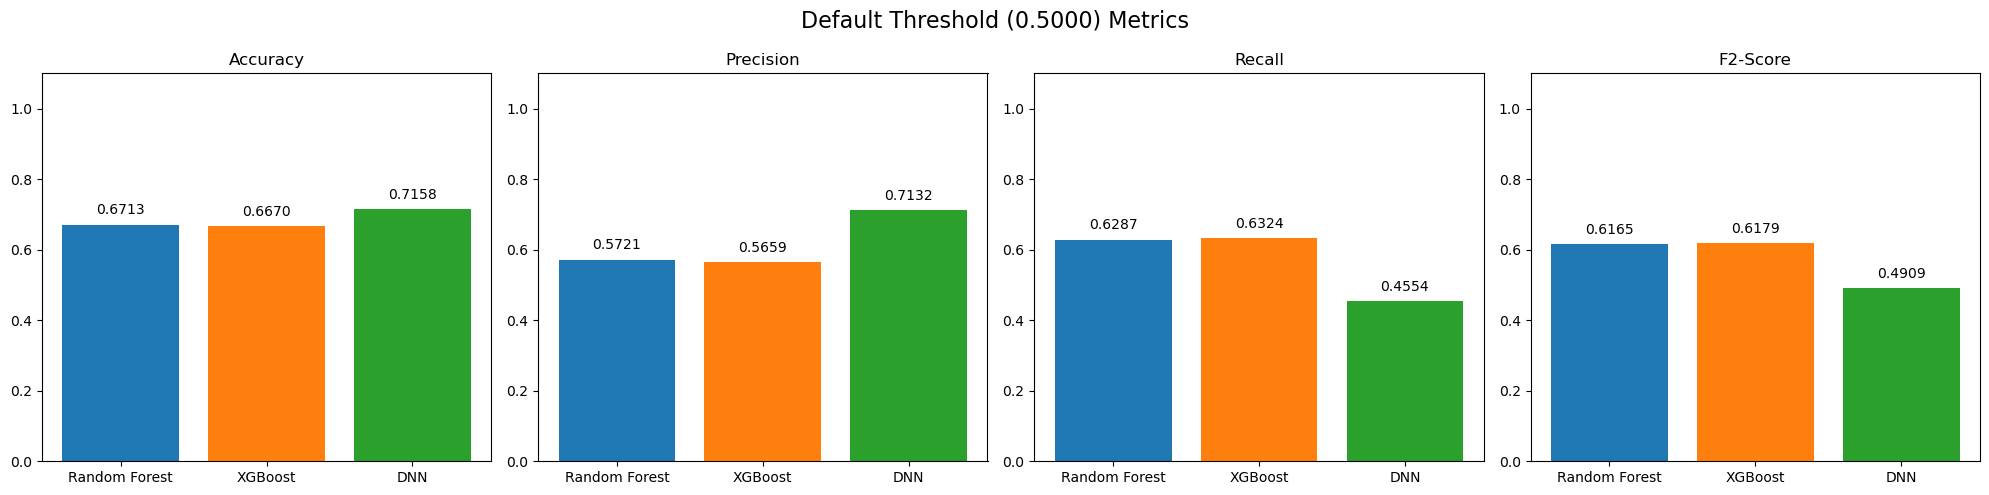

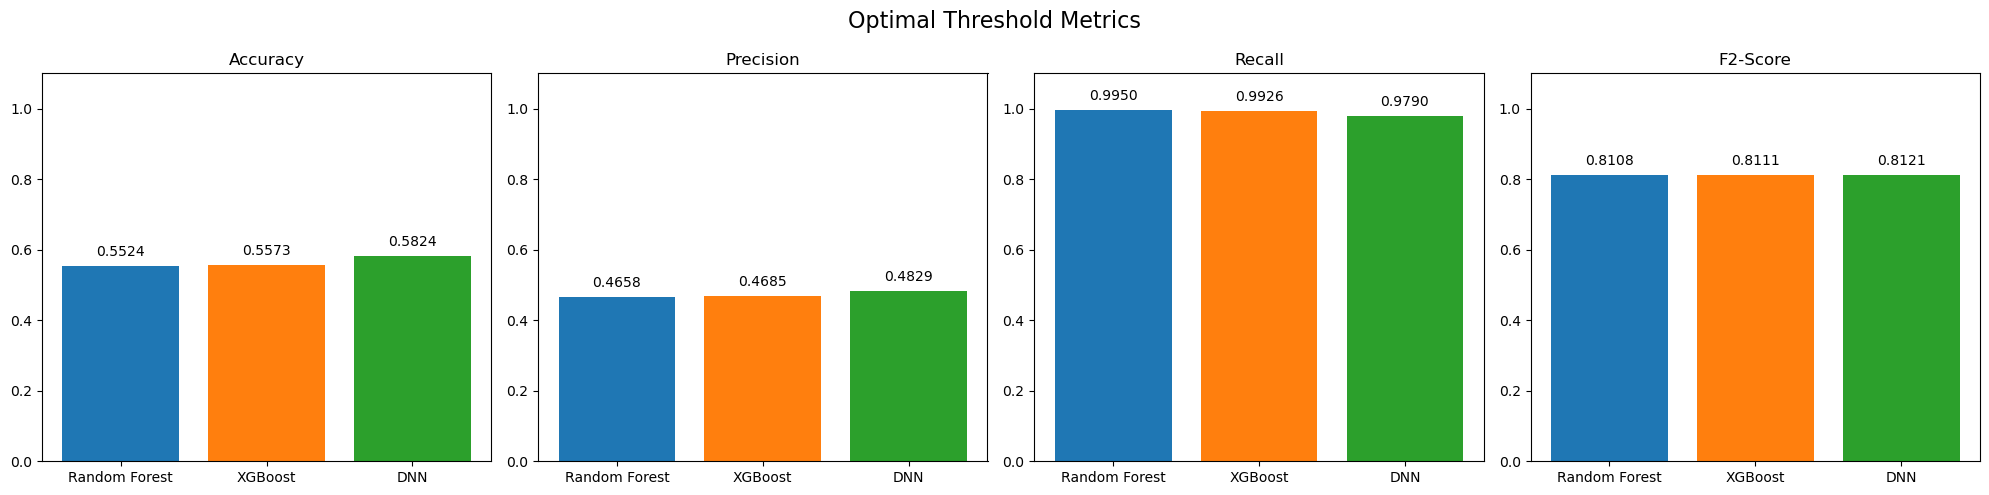

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Default Threshold
models = ['Random Forest', 'XGBoost', 'DNN']
metrics_default = {
    'Accuracy': [0.6713, 0.6670, 0.7158],
    'Precision': [0.5721, 0.5659, 0.7132],
    'Recall': [0.6287, 0.6324, 0.4554],
    'F2-Score': [0.6165, 0.6179, 0.4909]
}

# Data for Optimal Threshold
metrics_optimal = {
    'Accuracy': [0.5524, 0.5573, 0.5824],
    'Precision': [0.4658, 0.4685, 0.4829],
    'Recall': [0.9950, 0.9926, 0.9790],
    'F2-Score': [0.8108, 0.8111, 0.8121]
}

def plot_metrics(metrics_dict, title):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=16)
    
    for i, (metric_name, values) in enumerate(metrics_dict.items()):
        ax = axes[i]
        bars = ax.bar(models, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax.set_title(metric_name)
        ax.set_ylim(0, 1.1)
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')
            
    plt.tight_layout()
    plt.show()

plot_metrics(metrics_default, 'Default Threshold (0.5000) Metrics')
plot_metrics(metrics_optimal, 'Optimal Threshold Metrics')

## 總結

### Is the pattern practically important?
雖然模型展示出了一定的預測能力與模式，但由於本次訓練使用的是擬合/合成的資料（或是教學用資料），因此訓練出來的具體決策門檻數值與變數權重並不具備直接落地的「實務價值」。實務上，若要真正部署模型，必須使用公司內部真實累積的交易紀錄來重新訓練與校準。

### What is the cost of acting on the pattern incorrectly?
邏輯上「偽陰性」(False Negative) 的代價會較高。因為判斷用戶會準時付款而核發額度，一旦該用戶最終違約，就會造成公司的實際資金損失（包含本金與代墊成本）。相對的，「偽陽性」(False Positive，把好客戶誤判為會違約) 雖然會損失該次的手續費或利息收入，但短期內並不會造成直接的資金缺口。這也是為何我們更看重 Recall 的原因。

### What limitations must be reported?
雖然我們透過調整閾值（如最佳化 F2-Score）來提升 Recall 以防堵違約者，但這不可避免地會導致 Precision 下降與 False Positive 增加。這意味著會有更多本來會準時還款的優質客戶被拒絕授信。這在實務上的限制與隱憂包括：
1. **客戶體驗變差**：過度嚴苛的授信會引發客戶不滿，損害品牌聲譽與忠誠度。
2. **營收成長受限**：將過多客戶擋在門外，會降低整體交易規模，限制公司的營收成長。因此，決策者必須在「控制違約損失」與「追求營收成長」之間尋找一個商業上可接受的平衡點。

### 為何 ROC-AUC 差不多，在 0.5 門檻下混淆矩陣卻是 DNN 對於 auctual 1 表現最差?
1. ROC-AUC 只看「相對順序」，不管「絕對數值」。也就是 TPR > FPR 在每筆資料設定為門檻時的情況。
2. 混淆矩陣 (0.5 門檻) 只看「絕對數值」
3. RF 與 XGBoost 會有 class_weight='balanced' 的預設，預測機率很容易就被推高到 0.5 以上。